# grahspj: Chimera Benchmark Notebook

This notebook provides a practical interface for running the Chimera stellar-mass benchmark from within Jupyter.

It covers three use cases:
- the built-in Chimera benchmark runner used by the CLI
- a low-`chimera_QSO_weight` COSMOS-like subset treated as effectively galaxy-only
- a high-`chimera_QSO_weight` subset that keeps the standard AGN-enabled Chimera configuration

Important caveat: the repository currently exposes only one formal benchmark API, `run_chimera_mass_benchmark()`. The COSMOS-like and AGN-heavy slices below are notebook-level analyses built from the same Chimera rows.


## Prerequisites

This notebook assumes:
- you are running from the `notebooks/` directory of this repository
- `grahspj` and its dependencies are installed
- the Chimera benchmark FITS files are present under `data/chimeras-2023-10-11/`
- a valid DSPS SSP file is available

By default the notebook looks for `../jaxqsofit/tempdata.h5` as a sibling checkout.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

project_root = Path.cwd().resolve().parent
src_root = project_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from grahspj.benchmark import (
    build_chimera_fit_config,
    compute_weighted_metrics,
    load_chimera_benchmark_dataset,
    run_chimera_mass_benchmark,
    select_chimera_subset,
)
from grahspj.core import GRAHSPJ
from grahspj.mplstyle import style_path

plt.style.use(style_path())


In [2]:
dsps_ssp_fn = project_root.parent / "jaxqsofit" / "tempdata.h5"
assert dsps_ssp_fn.is_file(), f"DSPS SSP file not found: {dsps_ssp_fn}"

dataset = load_chimera_benchmark_dataset(project_root)
subset = select_chimera_subset(dataset, project_root)

qso_weights = np.array([row["chimera_QSO_weight"] for row in subset], dtype=float)
redshifts = np.array([row["redshift"] for row in subset], dtype=float)

print("Deterministic subset size:", len(subset))
print("QSO-weight percentiles:", np.percentile(qso_weights, [0, 25, 50, 75, 90, 95, 100]))
print("Redshift percentiles:", np.percentile(redshifts, [0, 25, 50, 75, 90, 95, 100]))


[benchmark] Loading Chimera photometry from /Users/colinburke/research/grahspj/data/chimeras-2023-10-11/chimeras-grahsp.fits
[benchmark] Loading Chimera truth table from /Users/colinburke/research/grahspj/data/chimeras-2023-10-11/chimeras-fullinfo.fits
[benchmark] Joined 18168 Chimera rows
[benchmark] Loading deterministic subset from /Users/colinburke/research/grahspj/data/chimeras-2023-10-11/benchmark_subset_ids.txt
[benchmark] Selected 270 benchmark rows
Deterministic subset size: 270
QSO-weight percentiles: [1.e-04 1.e-03 1.e-02 1.e-01 1.e+00 1.e+00 1.e+00]
Redshift percentiles: [0.0785     0.52737501 0.9016     1.64932498 2.79908993 3.10383004
 3.67000008]


In [3]:
cosmos_like_rows = [row for row in subset if float(row["chimera_QSO_weight"]) <= 1.0e-3]
agn_like_rows = [row for row in subset if float(row["chimera_QSO_weight"]) >= 1.0e-1]

print("COSMOS-like low-QSO subset:", len(cosmos_like_rows))
print("AGN-contaminated subset:", len(agn_like_rows))

print("Example COSMOS-like row:", cosmos_like_rows[0]["id"], cosmos_like_rows[0]["ID_COSMOS"], cosmos_like_rows[0]["chimera_QSO_weight"])
print("Example AGN-like row:", agn_like_rows[0]["id"], agn_like_rows[0]["ID_COSMOS"], agn_like_rows[0]["chimera_QSO_weight"])


COSMOS-like low-QSO subset: 90
AGN-contaminated subset: 90
Example COSMOS-like row: 135639.12+051950.9_712542_0.001 712542 0.001
Example AGN-like row: 174112.44+535632.5_496869_0.3 496869 0.3


## Built-In Chimera Benchmark

This is the same path used by `grahspj-benchmark` and `python -m grahspj.benchmark`.

It always uses the standard Chimera fit configuration, including the AGN component model seeded from each row photometry. For notebook iteration, start with a small `limit` and `num_workers=1`.


## Custom Subset Benchmarks

The helper below runs the same MAP fitting path row by row and computes the same weighted stellar-mass metrics.

For the COSMOS-like subset, the notebook turns AGN fitting off explicitly:

- `cfg.agn.fit_agn = False`

This removes the AGN parameter block entirely and makes the slice genuinely host-only.


In [12]:
def run_subset_mass_benchmark(
    rows,
    label,
    *,
    limit=10,
    galaxy_only=False,
    map_steps=600,
    learning_rate=5e-3,
):
    selected = list(rows[:limit] if limit is not None else rows)
    out_rows = []

    for idx, row in enumerate(selected, start=1):
        cfg = build_chimera_fit_config(row, dsps_ssp_fn=str(dsps_ssp_fn))
        cfg.inference.map_steps = int(map_steps)
        cfg.inference.learning_rate = float(learning_rate)

        if galaxy_only:
            cfg.agn.fit_agn = False

        try:
            fitter = GRAHSPJ(cfg)
            fit_result = fitter.fit(
                fit_method="optax+nuts",
                prior_config=cfg.prior_config,
                dsps_ssp_fn=cfg.galaxy.dsps_ssp_fn,
                optax_steps=cfg.inference.map_steps,
                optax_lr=cfg.inference.learning_rate,
                nuts_warmup=50,
                nuts_samples=50,
                plot_fig=False,
                save_fig=False,
                save_result=False,
                progress_bar=False,
            )
            summary = fit_result["summary"]
            logm_fit = float(summary["log_stellar_mass_median"])
        except Exception as exc:
            print(f"[{label}] failed on {row['id']}: {type(exc).__name__}: {exc}")
            logm_fit = np.nan

        out_rows.append(
            {
                "id": row["id"],
                "ID_COSMOS": row["ID_COSMOS"],
                "redshift": float(row["redshift"]),
                "chimera_QSO_weight": float(row["chimera_QSO_weight"]),
                "resample_weight": float(row["resample_weight"]),
                "log_stellar_mass_truth": float(row["log_stellar_mass_truth"]),
                "log_stellar_mass_fit": logm_fit,
            }
        )
        print(f"[{label}] {idx:03d}/{len(selected)} {row['id']} -> {logm_fit:.3f}")

    finite_rows = [row for row in out_rows if np.isfinite(row["log_stellar_mass_fit"])]
    if finite_rows:
        metrics = compute_weighted_metrics(
            np.array([row["log_stellar_mass_fit"] for row in finite_rows], dtype=float),
            np.array([row["log_stellar_mass_truth"] for row in finite_rows], dtype=float),
            np.array([row["resample_weight"] for row in finite_rows], dtype=float),
        )
    else:
        metrics = {
            "weighted_bias": np.nan,
            "weighted_mae": np.nan,
            "weighted_rmse": np.nan,
            "weighted_medae": np.nan,
            "weighted_pearson": np.nan,
        }

    metrics["n_rows"] = len(out_rows)
    metrics["n_finite_rows"] = len(finite_rows)
    metrics["finite_fit_fraction"] = len(finite_rows) / max(1, len(out_rows))

    return {"label": label, "rows": out_rows, "metrics": metrics}

    
def plot_subset_result(result):
    rows = result["rows"]
    fit = np.array([row["log_stellar_mass_fit"] for row in rows], dtype=float)
    truth = np.array([row["log_stellar_mass_truth"] for row in rows], dtype=float)
    qso = np.array([row["chimera_QSO_weight"] for row in rows], dtype=float)
    finite = np.isfinite(fit) & np.isfinite(truth) & np.isfinite(qso) & (qso > 0)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    log_qso = np.log10(qso[finite])
    sc0 = axes[0].scatter(truth[finite], fit[finite], c=log_qso, s=26, cmap="viridis")

    if np.any(finite):
        lo = float(min(np.min(truth[finite]), np.min(fit[finite])))
        hi = float(max(np.max(truth[finite]), np.max(fit[finite])))
        axes[0].plot([lo, hi], [lo, hi], color="black", ls="--", lw=1.0)

    axes[0].set_xlabel("Truth log stellar mass")
    axes[0].set_ylabel("Fit log stellar mass")
    axes[0].set_title(result["label"])

    resid = fit - truth
    axes[1].scatter(qso[finite], resid[finite], s=26)
    axes[1].axhline(0.0, color="black", ls="--", lw=1.0)
    axes[1].set_xscale("log")
    axes[1].set_xlabel("chimera_QSO_weight")
    axes[1].set_ylabel("Fit - Truth")
    axes[1].set_title("Residual vs QSO weight")

    fig.colorbar(sc0, ax=axes[0], label="log10(chimera_QSO_weight)")

    fig.tight_layout()
    return fig


In [16]:
cosmos_like_benchmark = run_subset_mass_benchmark(
    cosmos_like_rows,
    "COSMOS-like low-QSO subset",
    limit=100,
    galaxy_only=False,
)

cosmos_like_benchmark["metrics"]


[COSMOS-like low-QSO subset] 001/90 135639.12+051950.9_712542_0.001 -> 10.427
[COSMOS-like low-QSO subset] 002/90 173506.26+543008.3_698114_0.0001 -> 9.014
[COSMOS-like low-QSO subset] 003/90 140709.34+012420.0_701398_0.0003 -> 10.472
[COSMOS-like low-QSO subset] 004/90 143145.60+143630.1_687210_0.0003 -> 10.499
[COSMOS-like low-QSO subset] 005/90 174242.76+542609.9_689045_0.0001 -> 11.210
[COSMOS-like low-QSO subset] 006/90 140637.60+141530.1_692379_0.001 -> 9.157
[COSMOS-like low-QSO subset] 007/90 142924.66+060055.5_696727_0.001 -> 10.517
[COSMOS-like low-QSO subset] 008/90 022113.14+010102.9_684643_0.001 -> 8.308
[COSMOS-like low-QSO subset] 009/90 173203.07+560518.3_711580_0.0001 -> 9.949
[COSMOS-like low-QSO subset] 010/90 202519.51+781111.1_704594_0.0001 -> 11.130
[COSMOS-like low-QSO subset] 011/90 022607.16-001704.0_688593_0.0003 -> 10.812
[COSMOS-like low-QSO subset] 012/90 022300.41+005250.0_690429_0.001 -> 9.226
[COSMOS-like low-QSO subset] 013/90 205707.66+752603.8_700482_

{'weighted_bias': 0.22215727325615822,
 'weighted_mae': 0.2503795618992743,
 'weighted_rmse': 0.35874973653606695,
 'weighted_medae': 0.19124108913241522,
 'weighted_pearson': 0.9701884340406739,
 'n_rows': 90,
 'n_finite_rows': 90,
 'finite_fit_fraction': 1.0}

In [17]:
agn_like_benchmark = run_subset_mass_benchmark(
    agn_like_rows,
    "AGN-contaminated subset",
    limit=100,
    galaxy_only=False,
)

agn_like_benchmark["metrics"]


[AGN-contaminated subset] 001/90 174112.44+535632.5_496869_0.3 -> 9.817
[AGN-contaminated subset] 002/90 093419.45+592904.4_707486_0.3 -> 10.946
[AGN-contaminated subset] 003/90 140248.97+070534.4_497237_1 -> 10.159
[AGN-contaminated subset] 004/90 142610.25+155128.2_496215_1 -> 11.281
[AGN-contaminated subset] 005/90 014916.01+143816.5_700060_1 -> 11.543
[AGN-contaminated subset] 006/90 021436.94+003150.7_697467_0.3 -> 10.477
[AGN-contaminated subset] 007/90 172026.70+554024.2_707524_1 -> 10.813
[AGN-contaminated subset] 008/90 143348.21+012937.6_708995_1 -> 10.507
[AGN-contaminated subset] 009/90 144242.62+302420.5_691909_0.1 -> 10.359
[AGN-contaminated subset] 010/90 173551.92+535515.6_700937_0.1 -> 10.325
[AGN-contaminated subset] 011/90 025735.33-001631.3_693680_0.1 -> 9.654
[AGN-contaminated subset] 012/90 015921.53+141043.1_702804_0.1 -> 10.190
[AGN-contaminated subset] 013/90 014534.36+143136.9_691993_0.3 -> 10.181
[AGN-contaminated subset] 014/90 190150.86+791420.9_700703_1 ->

{'weighted_bias': 0.9781619238171076,
 'weighted_mae': 1.0468931729057473,
 'weighted_rmse': 1.3630294195664547,
 'weighted_medae': 0.7934694684027735,
 'weighted_pearson': 0.427963398366387,
 'n_rows': 90,
 'n_finite_rows': 90,
 'finite_fit_fraction': 1.0}

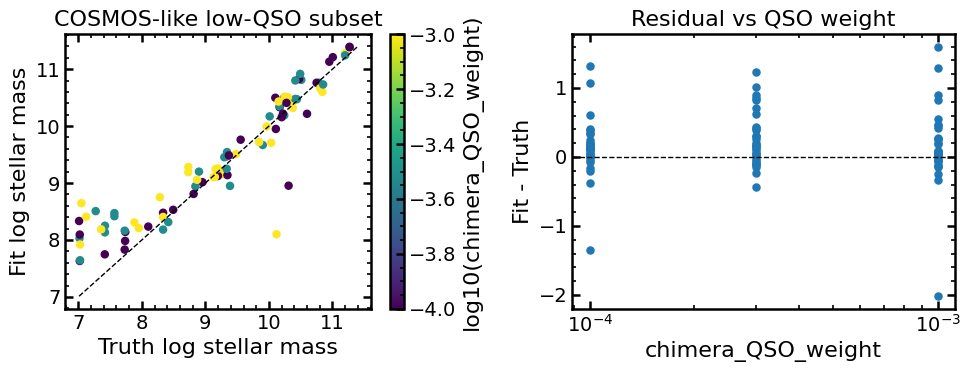

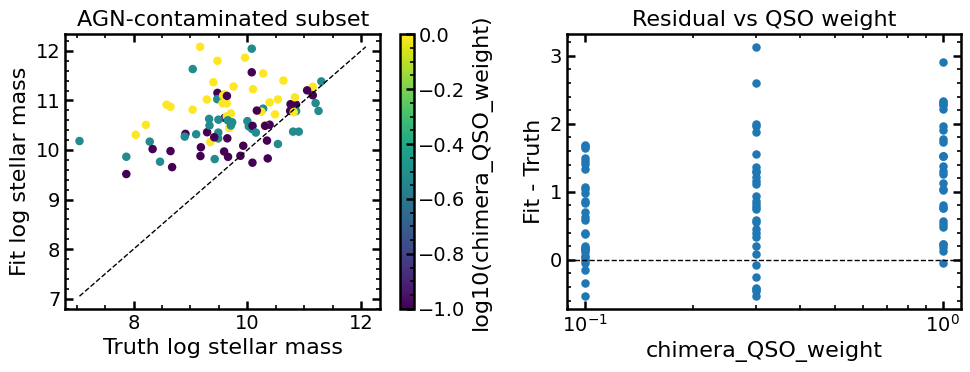

In [18]:
plot_subset_result(cosmos_like_benchmark);
plot_subset_result(agn_like_benchmark);
plt.show()


## Notes

- The official benchmark is the only built-in regression path in the package today.
- The COSMOS-like and AGN-like slices in this notebook are analysis conveniences, not separate packaged datasets.
- The COSMOS-like slice is run with `cfg.agn.fit_agn = False`, so the AGN block is removed entirely.
- Increase `limit`, `map_steps`, or switch to the CLI benchmark once you are satisfied the notebook path is behaving as expected.
